In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install diffusers transformers accelerate safetensors datasets
!pip install fsspec==2025.3.0 --upgrade

In [3]:
!git clone https://github.com/huggingface/diffusers
%cd diffusers
!pip install -e .  # Cài đặt diffusers từ source

fatal: destination path 'diffusers' already exists and is not an empty directory.
/content/diffusers
Obtaining file:///content/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.36.0.dev0-0.editable-py3-none-any.whl size=11380 sha256=b46bf0c145dc20bf784c72a9939905c199565cc3e986d123290234da36bc73ef
  Stored in directory: /tmp/pip-ephem-wheel-cache-emw7e6l0/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0.dev0
    Uninstalling diffusers-0.36.0.dev0:
      Successfully uninstalled diffusers-0.36.0.dev0


In [7]:
from diffusers import DiffusionPipeline
import torch

import os
# model_path = os.path.expanduser("~/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14")
# pipe = DiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16)


pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe.to("cuda")
pipe.safety_checker = None  # Tắt bộ lọc NSFW

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

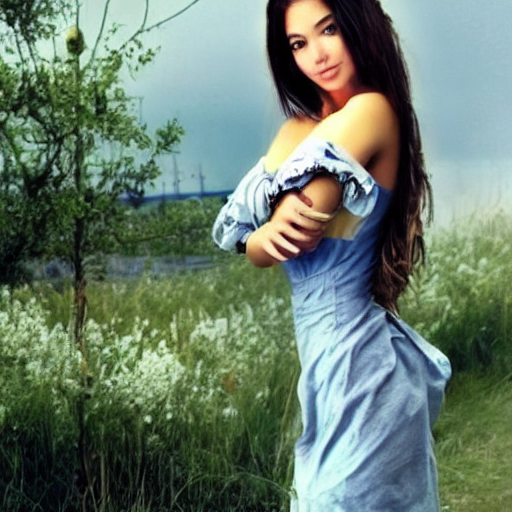

In [14]:
prompt = "a photo a beautyful girl"
image = pipe(prompt).images[0]
image.save("astronaut_rides_horse.png")
# image.show()
display(image)

In [ ]:
from google.colab import files
files.download("astronaut_rides_horse.png")

In [ ]:
!ls ~/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14

In [ ]:

  # --pretrained_model_name_or_path="~/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14" \
!accelerate launch diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --instance_data_dir="/content/drive/MyDrive/GenImageAI" \
  --output_dir="./pokemon_lora" \
  --instance_prompt="a photo of noname" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --train_text_encoder \
  --max_train_steps=1000


In [ ]:
# Tích hợp trọng số LoRA từ tệp .safetensors
lora_weights_path = "/content/pokemon_lora/pytorch_lora_weights.safetensors"  # Đường dẫn tới tệp của bạn
pipe.load_lora_weights(lora_weights_path)

# Chuyển pipeline sang GPU (nếu có)
pipe = pipe.to("cuda")

In [ ]:
# !cat pokemon_dataset/0.txt
!ls pokemon_lora